In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    f1_score
)

In [6]:
from google.colab import files


print("Please upload credit_card_transactions.csv")
uploaded = files.upload()
filename = next(iter(uploaded))

# Load into DataFrame
df = pd.read_csv(filename)

print("Shape:", df.shape)
print("\nColumn info:")
df.info()

display(df.head())

Please upload credit_card_transactions.csv


Saving credit_card_transactions.csv to credit_card_transactions (1).csv
Shape: (1000, 8)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        1000 non-null   int64  
 1   TransactionAmount    1000 non-null   float64
 2   TransactionHour      1000 non-null   int64  
 3   CustomerAge          1000 non-null   int64  
 4   AccountAgeDays       1000 non-null   int64  
 5   NumPrevTransactions  1000 non-null   int64  
 6   DistanceFromHomeKM   1000 non-null   float64
 7   IsFraud              1000 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


,TransactionID,TransactionAmount,TransactionHour,CustomerAge,AccountAgeDays,NumPrevTransactions,DistanceFromHomeKM,IsFraud
0,1,80.39,10,66,1410,36,8.63,0
1,2,66.20,15,64,1974,33,4.59,0
2,3,67.20,10,44,692,36,1.60,0
3,4,131.30,10,40,2061,23,6.67,0
4,5,74.73,7,62,395,24,8.92,0


In [7]:
fraud_counts = df["IsFraud"].value_counts()
fraud_pct = df["IsFraud"].value_counts(normalize=True) * 100

print("Class counts:\n", fraud_counts)
print("\nClass percentage:\n", fraud_pct.round(2))

display(pd.DataFrame({"Counts": fraud_counts, "Percentage (%)": fraud_pct.round(2)}))


Class counts:
 IsFraud
0    940
1     60
Name: count, dtype: int64

Class percentage:
 IsFraud
0    94.0
1     6.0
Name: proportion, dtype: float64


,Counts,Percentage (%)
IsFraud,,
0,940,94.0
1,60,6.0


In [8]:
print("Overall statistics:")
display(df.describe().round(2))

print("\nAverage values, Normal vs Fraud:")
display(df.groupby("IsFraud").mean(numeric_only=True).round(2))

Overall statistics:


,TransactionID,TransactionAmount,TransactionHour,CustomerAge,AccountAgeDays,NumPrevTransactions,DistanceFromHomeKM,IsFraud
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,500.50,111.09,13.13,43.56,1370.76,23.65,19.44,0.06
std,288.82,146.07,4.58,14.79,875.23,7.25,43.82,0.24
min,1.00,2.42,0.00,18.00,1.00,0.00,0.18,0.00
25%,250.75,41.97,10.00,31.00,585.75,21.00,4.76,0.00
50%,500.50,72.62,13.00,43.00,1403.00,24.00,8.48,0.00
75%,750.25,121.54,16.00,56.00,2084.50,28.00,14.65,0.00
max,1000.00,1304.27,23.00,69.00,2999.00,42.00,500.43,1.00



Average values, Normal vs Fraud:


,TransactionID,TransactionAmount,TransactionHour,CustomerAge,AccountAgeDays,NumPrevTransactions,DistanceFromHomeKM
IsFraud,,,,,,,
0,500.98,81.95,13.43,43.57,1456.42,25.00,9.78
1,492.95,567.63,8.45,43.47,28.67,2.47,170.85


In [9]:
feature_cols = [
    "TransactionAmount",
    "TransactionHour",
    "CustomerAge",
    "AccountAgeDays",
    "NumPrevTransactions",
    "DistanceFromHomeKM"
]

X = df[feature_cols]
y = df["IsFraud"]
transaction_ids = df["TransactionID"]

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())



X shape: (1000, 6)
y shape: (1000,)


,TransactionAmount,TransactionHour,CustomerAge,AccountAgeDays,NumPrevTransactions,DistanceFromHomeKM
0,80.39,10,66,1410,36,8.63
1,66.20,15,64,1974,33,4.59
2,67.20,10,44,692,36,1.60
3,131.30,10,40,2061,23,6.67
4,74.73,7,62,395,24,8.92


In [10]:
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, transaction_ids,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train), " | Fraud in train:", y_train.sum())
print("Testing samples :", len(X_test), " | Fraud in test :", y_test.sum())

display(X_train.head(3))

Training samples: 700  | Fraud in train: 42
Testing samples : 300  | Fraud in test : 18


,TransactionAmount,TransactionHour,CustomerAge,AccountAgeDays,NumPrevTransactions,DistanceFromHomeKM
995,67.34,11,36,1889,23,1.51
734,52.70,16,47,238,27,15.39
924,35.77,13,67,2411,28,19.68


In [11]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_sm.value_counts())

display(pd.DataFrame({"Before SMOTE": y_train.value_counts(), "After SMOTE": y_train_sm.value_counts()}))


Before SMOTE:
 IsFraud
0    658
1     42
Name: count, dtype: int64

After SMOTE:
 IsFraud
0    658
1    658
Name: count, dtype: int64


,Before SMOTE,After SMOTE
IsFraud,,
0,658,658
1,42,658


In [12]:

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train_sm, y_train_sm)
print("Model trained successfully.")

Model trained successfully.


In [13]:
y_pred_default = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]   # probability of class 1 (fraud)

print("Confusion Matrix (rows=actual, cols=predicted):")
print(confusion_matrix(y_test, y_pred_default))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_default, target_names=["Normal", "Fraud"]))

print("ROC-AUC score:", round(roc_auc_score(y_test, y_proba), 3))

Confusion Matrix (rows=actual, cols=predicted):
[[279   3]
 [  0  18]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99       282
       Fraud       0.86      1.00      0.92        18

    accuracy                           0.99       300
   macro avg       0.93      0.99      0.96       300
weighted avg       0.99      0.99      0.99       300

ROC-AUC score: 0.995


In [14]:
thresholds = np.arange(0.1, 0.95, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    report = classification_report(y_test, y_pred_t, output_dict=True, zero_division=0)
    results.append({
        "Threshold": round(t, 2),
        "Precision": round(report["1"]["precision"], 3),
        "Recall": round(report["1"]["recall"], 3),
        "F1-score": round(f1, 3)
    })

results_df = pd.DataFrame(results)
best_threshold = 0.25

display(results_df)

,Threshold,Precision,Recall,F1-score
0,0.10,0.857,1.0,0.923
1,0.15,0.857,1.0,0.923
2,0.20,0.857,1.0,0.923
3,0.25,0.857,1.0,0.923
4,0.30,0.857,1.0,0.923
5,0.35,0.857,1.0,0.923
6,0.40,0.857,1.0,0.923
7,0.45,0.857,1.0,0.923
8,0.50,0.857,1.0,0.923
9,0.55,0.857,1.0,0.923


In [15]:
y_pred_tuned = (y_proba >= best_threshold).astype(int)

print(f"Results at tuned threshold = {best_threshold}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=["Normal", "Fraud"]))

Results at tuned threshold = 0.25

Confusion Matrix:
[[279   3]
 [  0  18]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99       282
       Fraud       0.86      1.00      0.92        18

    accuracy                           0.99       300
   macro avg       0.93      0.99      0.96       300
weighted avg       0.99      0.99      0.99       300



Feature importance scores:


,Importance Score
NumPrevTransactions,1.0
TransactionAmount,0.0
TransactionHour,0.0
CustomerAge,0.0
AccountAgeDays,0.0
DistanceFromHomeKM,0.0


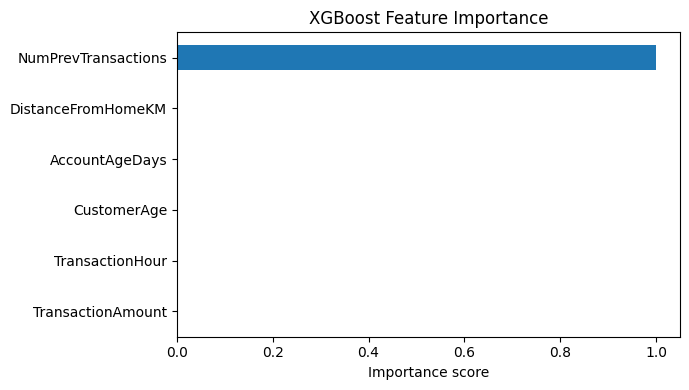

In [16]:
importances = pd.Series(model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

print("Feature importance scores:")
display(importances.to_frame(name="Importance Score").round(3))

plt.figure(figsize=(7, 4))
importances.sort_values().plot(kind="barh")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance score")
plt.tight_layout()
plt.show()

In [17]:
submission = pd.DataFrame({
    "TransactionID": id_test.values,
    "FraudProbability": np.round(y_proba, 4),
    "PredictedIsFraud": y_pred_tuned
})

submission.to_csv("submission.csv", index=False)
files.download("submission.csv")
display(submission.head(10))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,TransactionID,FraudProbability,PredictedIsFraud
0,388,0.0015,0
1,775,0.0015,0
2,347,0.0015,0
3,724,0.9985,1
4,485,0.0015,0
5,689,0.0015,0
6,555,0.0015,0
7,850,0.0015,0
8,905,0.0015,0
9,599,0.0015,0


In [20]:
summary = pd.DataFrame([
    {
        "Setting": "Default threshold (0.5)",
        "Precision": round(classification_report(y_test, y_pred_default, output_dict=True, zero_division=0)["1"]["precision"], 3),
        "Recall": round(classification_report(y_test, y_pred_default, output_dict=True, zero_division=0)["1"]["recall"], 3),
        "F1-score": round(f1_score(y_test, y_pred_default), 3)
    },
    {
        "Setting": f"Tuned threshold ({best_threshold})",
        "Precision": round(classification_report(y_test, y_pred_tuned, output_dict=True, zero_division=0)["1"]["precision"], 3),
        "Recall": round(classification_report(y_test, y_pred_tuned, output_dict=True, zero_division=0)["1"]["recall"], 3),
        "F1-score": round(f1_score(y_test, y_pred_tuned), 3)
    }
])
display(summary)

,Setting,Precision,Recall,F1-score
0,Default threshold (0.5),0.857,1.0,0.923
1,Tuned threshold (0.25),0.857,1.0,0.923
